In [47]:
#import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, classification_report

In [48]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/CDAC_2026_ML/ASSIGNMENT/AmesHousing - AmesHousing.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Section 1: Data Loading &amp; Exploratory Data Analysis (EDA)

In [49]:
#Q1. Load the House Prices dataset using pandas and display the first 5 rows. What is the shape of the dataset? Check the column names and data types.

print("First 5 rows: \n")
print(df.head(5))
print()

print("\nShape of the dataset: \n")
print(df.shape)
print()


print("\nColumns names: \n")
print(df.columns)
print()

print("\nData type of the dataset: \n")
print(df.dtypes)
print()

First 5 rows: 

   Order        PID  MS SubClass  ... Sale Type  Sale Condition  SalePrice
0      1  526301100           20  ...        WD          Normal     215000
1      2  526350040           20  ...        WD          Normal     105000
2      3  526351010           20  ...        WD          Normal     172000
3      4  526353030           20  ...        WD          Normal     244000
4      5  527105010           60  ...        WD          Normal     189900

[5 rows x 82 columns]


Shape of the dataset: 

(2930, 82)


Columns names: 

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'E

SalesPrice analysis:

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Histogram of SalePrice: 



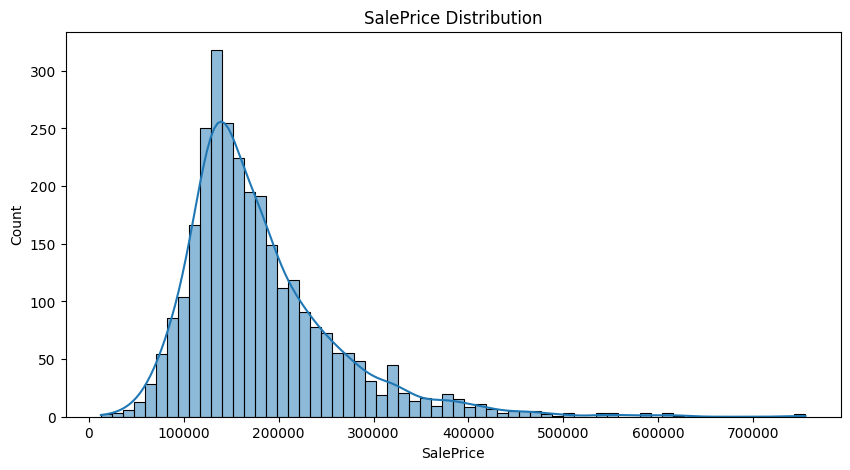


Boxplot of SalePrice: 



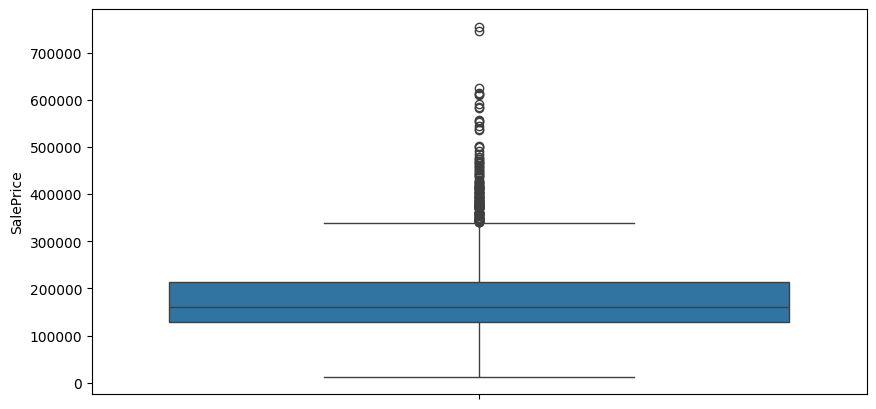


Skewness of target var. 'SalesPrice: 

1.7435000757376466


In [50]:
#Q2. Check the target variable SalePrice distribution:
#1. Minimum, maximum, mean, median, and standard deviation

print("SalesPrice analysis:\n")
print(df['SalePrice'].describe())
print()


#2. Plot histogram and boxplot of SalePrice

print("Histogram of SalePrice: \n")
plt.figure(figsize=(10,5))
sns.histplot(df['SalePrice'], kde=True)
plt.title("SalePrice Distribution")
plt.show()
print()

print("Boxplot of SalePrice: \n")
plt.figure(figsize=(10,5))
sns.boxplot(df['SalePrice'])
plt.show()
print()


#3. Is the target variable skewed? Explain
print("Skewness of target var. 'SalesPrice: \n")
print(df['SalePrice'].skew())



In [51]:
#Q3. Calculate descriptive statistics for all numerical features using describe().

df.describe()


#Identify:
#1 Which feature has the highest average value?

#ANS: Feature: PID	and its mean is: 714,464,496.99

#2 Which feature has the highest standard deviation?

#ANS: Feature: PID


#3 Are there any features with many missing values or very low variance?

#ANS: yes there are many missing values and Low Variance Features: Examples: Street, Utilities

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2928.000000,2928.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2771.000000,2929.000000,2929.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,559.262547,1051.614544,1159.557679,335.455973,4.676792,1499.690444,0.431352,0.061134,1.566553,0.379522,2.854266,1.044369,6.443003,0.599317,1978.132443,1.766815,472.819734,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,439.494153,440.615067,391.890885,428.395715,46.310510,505.508887,0.524820,0.245254,0.552941,0.502629,0.827731,0.214076,1.572964,0.647921,25.528411,0.760566,215.046549,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,219.000000,793.000000,876.250000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,466.000000,990.000000,1084.000000,0.000000,0.000000,1442.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,802.000000,1302.000000,1384.000000,703.750000,0.000000,1742.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


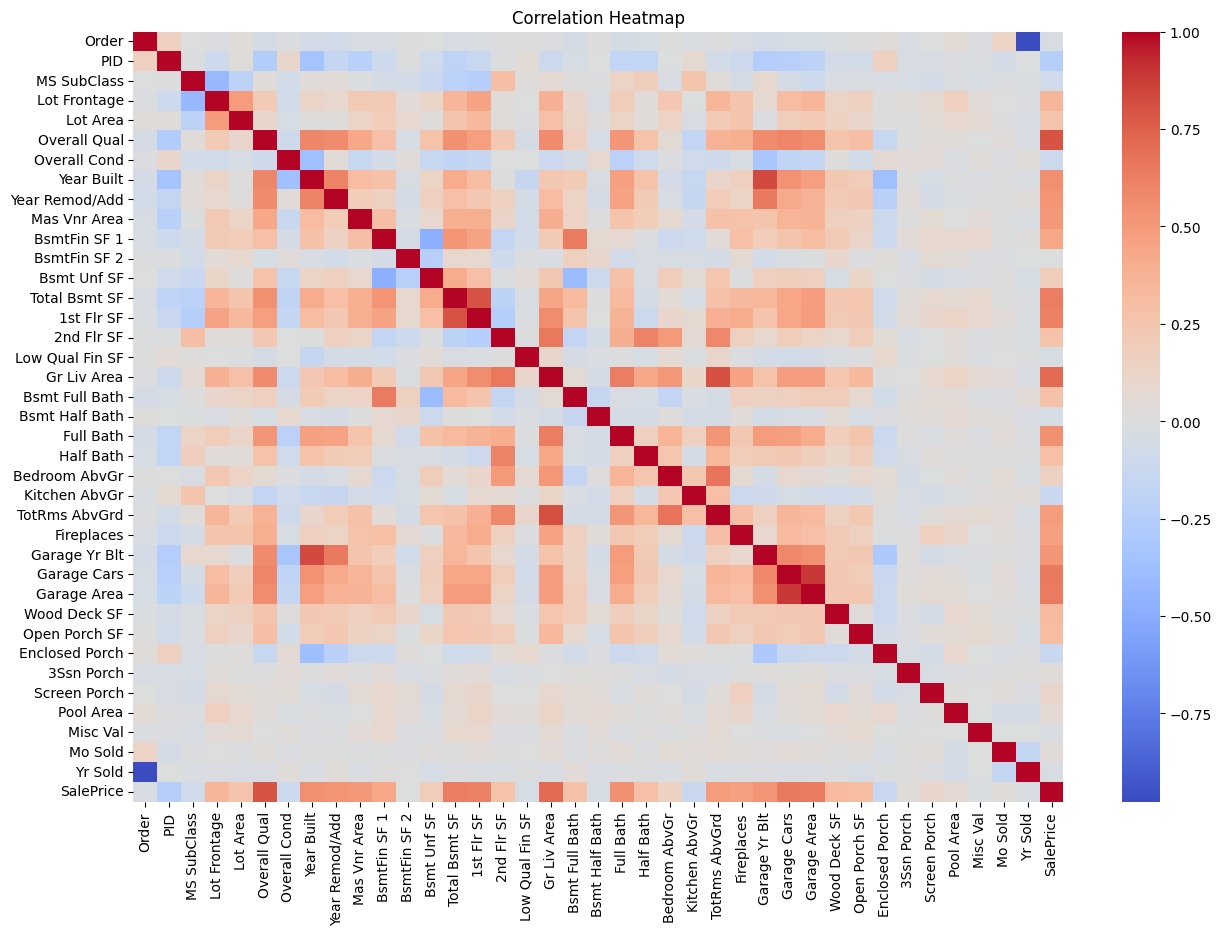

In [52]:
#Q4. Create a correlation heatmap for numerical features using seaborn. Identify:
#1 Which 3 features have the highest positive correlation with SalePrice?
#2 Which features are highly correlated with each other (correlation &gt; 0.8)?
#3 Suggest potential feature removal to reduce multicollinearity


plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Answer1 : The three features with the highest positive correlation with SalePrice are Overall Qual, Gr Liv Area, and Garage Cars.
#Answer2: These feature pairs are highly correlated and may cause multicollinearity.
#Answer3: To reduce multicollinearity, remove Garage Area, Garage Yr Blt, TotRms AbvGrd, and 1st Flr SF, while retaining their more informative counterparts.

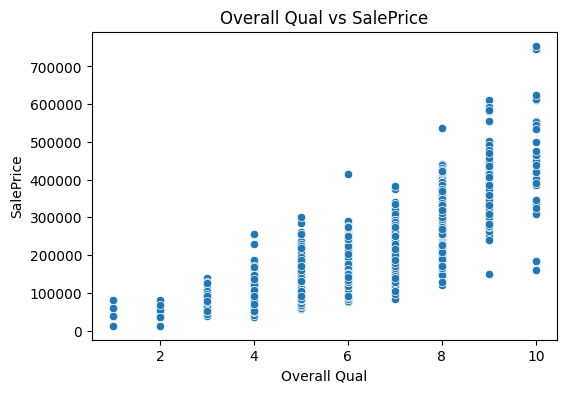

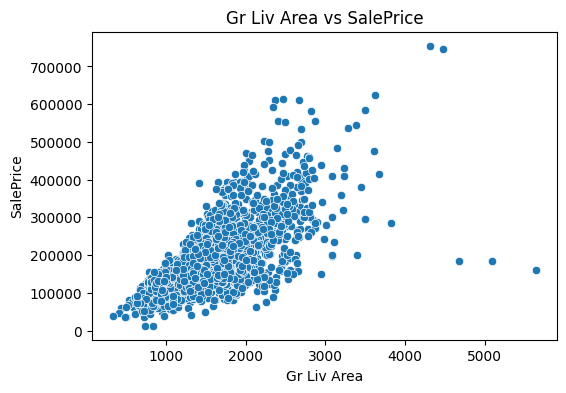

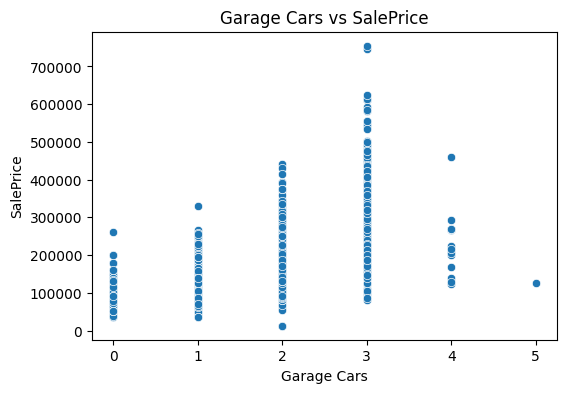

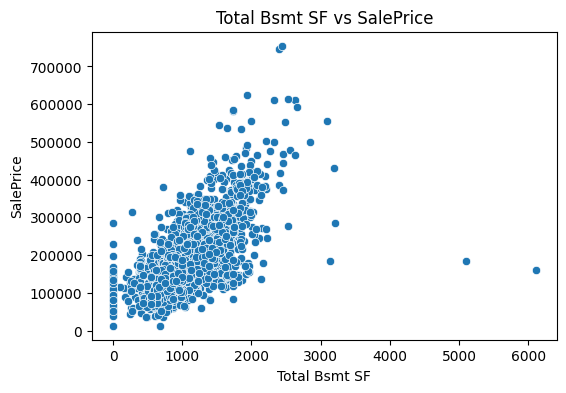

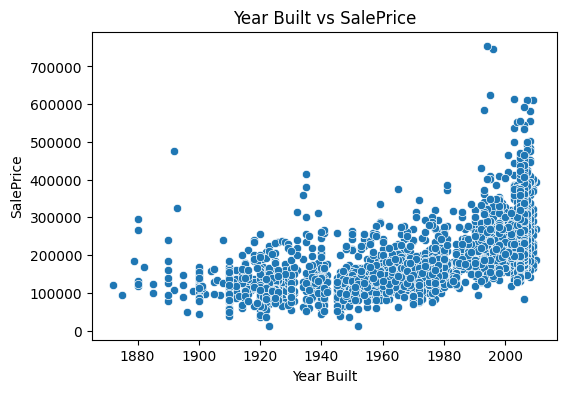

In [53]:
#Q5. Create scatter plots or box plots for the top 5 features most correlated with SalePrice
#such as:
#1 OverallQual
#2 GrLivArea
#3 GarageCars
#4 TotalBsmtSF
#5 YearBuilt
#What patterns do you observe in relation to house prices?

features = ['Overall Qual', 'Gr Liv Area','Garage Cars', 'Total Bsmt SF','Year Built']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[feature], y=df['SalePrice'])
    plt.title(f'{feature} vs SalePrice')
    plt.show()

###Section 2: Data Preprocessing

In [54]:
#Q6. Check and handle missing values in the dataset:

#1 Identify columns with missing values

missing_values = df.isnull().sum()
# Display only columns having missing values
missing_values = missing_values[missing_values > 0]
print(missing_values.sort_values(ascending=False))
print()


#2 Decide whether to drop or impute them

drop_cols = ['Pool QC', 'Misc Feature', 'Alley']
df.drop(columns=drop_cols, inplace=True)


#3 Fill numerical missing values with mean/median and categorical missing values with mode
# Numerical Columns → Median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns → Mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64



/tmp/ipykernel_6097/2876158500.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_6097/2876158500.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [55]:
print(df.isnull().sum().sum()) #verify missing values are removed

0


In [56]:
#Q7. Encode categorical variables:
#1 Identify all categorical columns

catego_cols = df.select_dtypes(include='object').columns
print("Number of Categorical Columns:", len(cat_cols))
print(cat_cols)
print()

#2. Apply label encoding or one-hot encoding where appropriate

df_encoded = pd.get_dummies(df, columns=catego_cols, drop_first=True)
print(df_encoded.shape)


#3. Explain why encoding is necessary for regression models
#Answer: As most of the algorithms like linear, SVM, lasso, ridge etc can only work on numerical data but sometimes the datasets contain categorical data which further have processing problem so we use various encoders to encode categorical data to numerical values



Number of Categorical Columns: 40
Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Fence', 'Sale Type', 'Sale Condition'],
      dtype='object')

(2930, 255)


In [57]:
#label encoder
le = LabelEncoder()

for col in catego_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [58]:
#Q8. Split the dataset into features (X) and target (y). Then apply Train-Test split:
#1 80% training, 20% testing
#2 Use random_state = 42
#3 Display the shape of X_train, X_test, y_train, y_test

#separate features and target var

X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (2344, 254)
X_test shape : (586, 254)
y_train shape: (2344,)
y_test shape : (586,)


In [59]:
#Q9. Apply feature scaling:
#1 Use StandardScaler for numerical variables
#2 Scale only the training data first, then transform test data
#3 Why is scaling important for models like Ridge, Lasso, Elastic Net, and SVR?

scaler = StandardScaler()

#fit on training data and then transform

X_train_scaled = scaler.fit_transform(X_train)

#fit on test data and then transform

X_test_scaled = scaler.transform(X_test)

#note: fit() -> performs mean and standard derivation from the training data and fit_transform() --> scaled data using those values

In [60]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (2344, 254)
X_test_scaled : (586, 254)


##Section 3: Linear Regression &amp; Regularization

In [61]:
#Q10. Implement Simple Linear Regression / Multiple Linear Regression:


lm = LinearRegression()

#1. Train a baseline regression model

lm.fit(X_train_scaled, y_train)

#2. Predict on test data

y_pred = lm.predict(X_test_scaled)

#3. Calculate RMSE, MAE, MSE, and R² Score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared error: ",mse)
print("Root Mean Squared error: ",rmse)
print("Mean Absolute error: ",mae)
print("R2 error: ",r2)

#4. Interpret the model performance

results = pd.DataFrame({
    "Metric":["RMSE","MAE","MSE","R² Score"],
    "Value":[rmse, mae, mse, r2]
})

print(results)

Mean Squared error:  853318561.9994795
Root Mean Squared error:  29211.616901491085
Mean Absolute error:  16293.447486957059
R2 error:  0.8935686360277405
     Metric         Value
0      RMSE  2.921162e+04
1       MAE  1.629345e+04
2       MSE  8.533186e+08
3  R² Score  8.935686e-01


In [62]:
#Q11. Implement Ridge Regression:

#1 Use Ridge(alpha=1.0)

ridge = Ridge(alpha=1.0)


#2 Train and predict

ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

#3 Calculate RMSE, MAE, and R²

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("RMSE :", rmse_ridge)
print("MAE  :", mae_ridge)
print("R² Score :", r2_ridge)

print()
#4 Compare Ridge with Linear Regression

compare= pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R² Score"],
    "Linear Regression": [rmse, mae, r2],
    "Ridge Regression": [rmse_ridge, mae_ridge, r2_ridge]
})

print(compare)

#5 Why does Ridge help with multicollinearity?

#Ans: Ridge Regression adds an L2 regularization penalty to the loss function. Multicollinearity occurs when features are highly correlated.

RMSE : 29094.26827550856
MAE  : 16288.658667443753
R² Score : 0.8944220285576235

     Metric  Linear Regression  Ridge Regression
0      RMSE       29211.616901      29094.268276
1       MAE       16293.447487      16288.658667
2  R² Score           0.893569          0.894422


In [63]:
#Q12. Implement Lasso Regression:

#1 Use Lasso(alpha=0.01) or tuned alpha

lasso = Lasso(alpha=0.01)

#2 Train and predict

lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled) #Predict on Test Data

#3 Calculate the same metrics

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAE :", mae_lasso)
print("R² Score :", r2_lasso)
print()

#4 Which features are reduced to zero?

lasso_coef = pd.Series(lasso.coef_, index=X_train.columns)

zero_features = lasso_coef[lasso_coef == 0]

print("Number of features reduced to zero:", len(zero_features))
print(zero_features.index.tolist())

#5 Why is Lasso useful for feature selection?

#ANS: Lasso Regression uses L1 Regularization.
#As, 1. It shrinks less important feature coefficients toward zero. 2. Features with zero coefficients are effectively removed from the model.
# Advantages of Lasso: Reduces overfitting , produces simpler models and removes irrelevant features.

MSE : 847201636.1122993
RMSE : 29106.72836497258
MAE : 16269.73058259306
R² Score : 0.8943315782564486

Number of features reduced to zero: 2
['Exterior 2nd_Other', 'Kitchen Qual_Po']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.020e+11, tolerance: 1.394e+09
  model = cd_fast.enet_coordinate_descent(


In [64]:
#Q13. Implement Elastic Net Regression:

#1 Use ElasticNet(alpha=0.01, l1_ratio=0.5)

elastic = ElasticNet(alpha=0.01, l1_ratio=0.5)

#2 Train and predict

elastic.fit(X_train_scaled, y_train)

y_pred_elastic = elastic.predict(X_test_scaled)

#3 Compare performance with Ridge and Lasso

mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
r2_elastic = r2_score(y_test, y_pred_elastic)

print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)
print("MAE :", mae_elastic)
print("R² Score :", r2_elastic)
print()

comparison= pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R² Score"],
    "Ridge": [rmse_ridge, mae_ridge, r2_ridge],
    "Lasso": [rmse_lasso, mae_lasso, r2_lasso],
    "Elastic Net": [rmse_elastic, mae_elastic, r2_elastic]
})

print(comparison)

#4 Which regularization method performs best and why?

#ANS: Elastic Net Regression performes best than L1 and L2. It achieved the highest R² Score and the lowest RMSE and MAE values, indicating better prediction accuracy.
# The L1 penalty helps in feature selection by reducing some coefficients to zero, while the L2 penalty helps handle multicollinearity by shrinking coefficient values.

# elastic: This combination makes the model more stable and less prone to overfitting.

# Ridge handles multicollinearity well but does not remove unnecessary features, whereas Lasso performs feature selection but may become unstable when features are highly correlated.

# Therefore, Elastic Net provides a balanced approach, resulting in improved generalization and better overall performance on the housing price dataset.



MSE : 847468011.9796836
RMSE : 29111.303852278477
MAE : 16457.32987328435
R² Score : 0.8942983541498165

     Metric         Ridge         Lasso   Elastic Net
0      RMSE  29094.268276  29106.728365  29111.303852
1       MAE  16288.658667  16269.730583  16457.329873
2  R² Score      0.894422      0.894332      0.894298


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.147e+10, tolerance: 1.394e+09
  model = cd_fast.enet_coordinate_descent(


##Section 4: Regression Models

In [65]:
#Q14. Implement Support Vector Regression (SVR):

#1 Use SVR(kernel='rbf')
#2 Train on scaled data

svr = SVR(kernel='rbf')

svr.fit(X_train_scaled, y_train)

#3 Predict house prices

y_pred_svr = svr.predict(X_test_scaled)

#4 Evaluate using RMSE, MAE, and R²

mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("MSE :", mse_svr)
print("RMSE :", rmse_svr)
print("MAE :", mae_svr)
print("R² Score :", r2_svr)


#5 Why is SVR suitable for complex non-linear data?

#ANS: SVR with the RBF (Radial Basis Function) kernel can capture complex non-linear relationships between features and house prices.

#The RBF kernel maps data into a higher-dimensional space where non-linear patterns become easier to learn.
#SVR is effective at handling high-dimensional datasets and reducing overfitting.
#It focuses on minimizing prediction error within a margin, making it robust to noise.

MSE : 8887627986.795753
RMSE : 94274.2169778978
MAE : 63786.0947451272
R² Score : -0.10852196499304023


In [66]:
#Q15. Apply Hyperparameter Tuning for SVR using GridSearchCV:

#1 Parameters: C = [0.1, 1, 10], gamma = [0.01, 0.1, 1], kernel = [&#39;rbf&#39;]
#2 Use 5-fold cross validation
#3 Find best parameters
#4 Evaluate the best model on test data


param_grid  = {
    'C': [0.1, 1, 10],
    'gamma':[0.01, 0.1, 1],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    estimator=SVR(),
    param_grid  = param_grid,
    cv=5,
    scoring= 'r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)


print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)


#Get Best Model

best_svr = grid.best_estimator_

#predict on test data

y_pred_best = best_svr.predict(X_test_scaled)


mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("RMSE :", rmse_best)
print("MAE :", mae_best)
print("R² Score :", r2_best)


Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross Validation Score: -0.05471326275806687
RMSE : 94084.46757352233
MAE : 63551.434661005216
R² Score : -0.10406412470189608


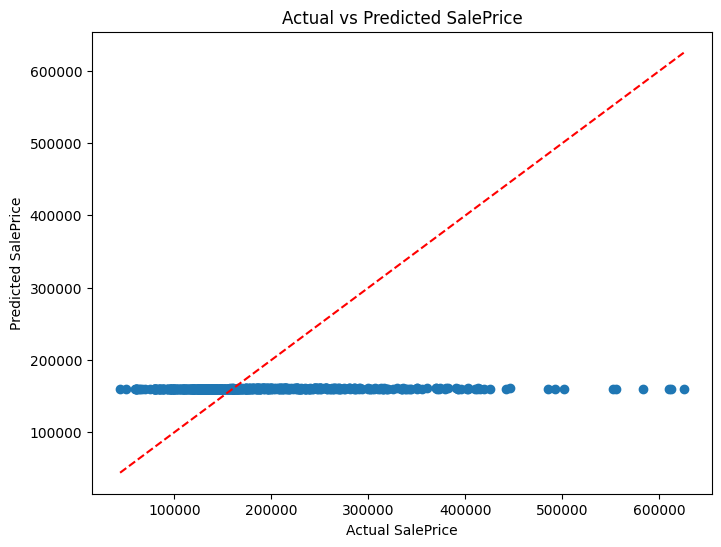

In [67]:
#Q16. Visualize model predictions:

# I assumesthe best SVR Model

#1 Plot actual vs predicted SalePrice for the best regression model
#2 Draw a regression line or scatter comparison

#3 What does the plot tell us about prediction accuracy?

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted SalePrice")
plt.show()

##Section 5: Model Comparison &amp; Advanced Techniques

In [68]:
#Q17. Compare all models using a comprehensive table:

compare = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "MSE", "R² Score"],
    "Linear Regression": [rmse, mae, mse, r2],
    "Ridge Regression": [rmse_ridge, mae_ridge, mse_ridge ,r2_ridge],
    "Lasso": [rmse_lasso, mae_lasso, mse_lasso, r2_lasso],
    "Elastic Net": [rmse_elastic, mae_elastic, mse_elastic, r2_elastic],
    "SVR": [rmse_svr, mae_svr, mse_svr, r2_svr],
    "Best Tuned Model": [rmse_best, mae_best, mse_best, r2_best]
})

print(compare)

# Linear Regression is performing much better than SVR

     Metric  Linear Regression  ...           SVR  Best Tuned Model
0      RMSE       2.921162e+04  ...  9.427422e+04      9.408447e+04
1       MAE       1.629345e+04  ...  6.378609e+04      6.355143e+04
2       MSE       8.533186e+08  ...  8.887628e+09      8.851887e+09
3  R² Score       8.935686e-01  ... -1.085220e-01     -1.040641e-01

[4 rows x 7 columns]


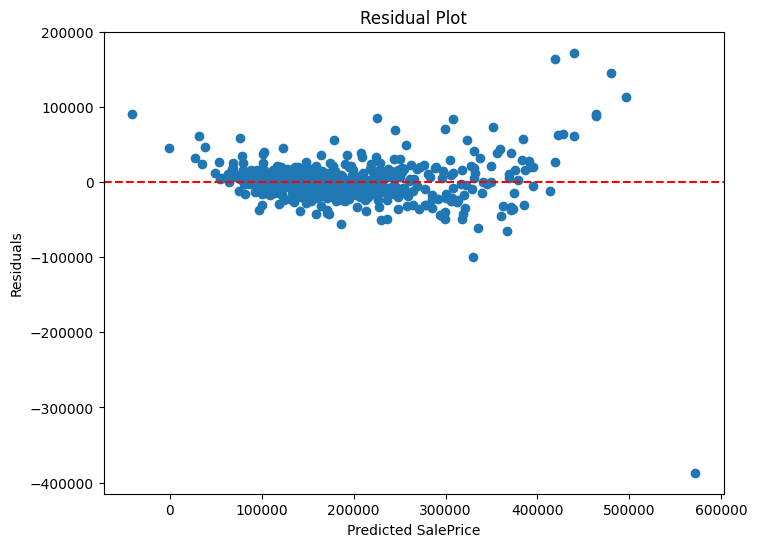

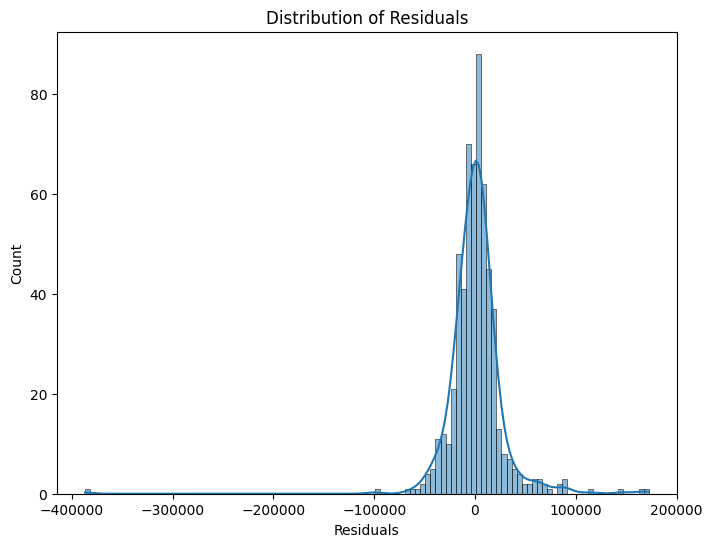

In [69]:
#Q18. Apply Residual Analysis:
#1 Plot residuals for the best model
#2 Check whether residuals are randomly distributed
#3 What does this indicate about model quality?
#4 Why is residual analysis important in regression?

#Calculate Residuals
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

print()

plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

In [70]:
#Q19. Feature Importance / Coefficient Analysis:
#For Ridge/Lasso/Elastic Net: identify features with highest coefficients
# For tree-based model if used: use feature_importances_
# Create a table:
#Rank Feature
#Name

#Importance /
#Coefficient Interpretation

#1 ? ? ?
#2 ? ? ?
#3 ? ? ?
#What do these features tell us about house pricing?


#Step 1: Extract Coefficients (Example: Ridge
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge.coef_
})

coef_df['Abs_Coefficient'] = abs(coef_df['Coefficient'])

top_features = coef_df.sort_values(
    by='Abs_Coefficient',
    ascending=False
).head(10)

print(top_features[['Feature', 'Coefficient']])

#For Lasso
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lasso.coef_
})

top_features = coef_df.reindex(
    coef_df.Coefficient.abs().sort_values(ascending=False).index
).head(10)

print(top_features)

#For Elastic Net
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': elastic.coef_
})

top_features = coef_df.reindex(
    coef_df.Coefficient.abs().sort_values(ascending=False).index
).head(10)

print(top_features)

               Feature   Coefficient
117  Roof Matl_CompShg  73907.217468
121  Roof Matl_Tar&Grv  53667.372166
122  Roof Matl_WdShake  35518.892567
123  Roof Matl_WdShngl  34493.754811
17         Gr Liv Area  16016.471206
230     Garage Qual_TA -15590.312204
227     Garage Qual_Fa -14105.292027
15          2nd Flr SF  14096.811510
118  Roof Matl_Membran  13208.803775
119    Roof Matl_Metal  12997.163247
               Feature   Coefficient
117  Roof Matl_CompShg  78109.948324
121  Roof Matl_Tar&Grv  56845.540319
122  Roof Matl_WdShake  37563.409483
123  Roof Matl_WdShngl  36220.909713
15          2nd Flr SF  24086.279500
230     Garage Qual_TA -17281.325603
227     Garage Qual_Fa -15635.646109
14          1st Flr SF  14238.855766
10        BsmtFin SF 1  14040.824708
118  Roof Matl_Membran  13952.136687
               Feature   Coefficient
117  Roof Matl_CompShg  46925.592348
121  Roof Matl_Tar&Grv  33520.030341
123  Roof Matl_WdShngl  23313.771758
122  Roof Matl_WdShake  22377.756643
1